In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data

plt.style.use('fivethirtyeight')
%matplotlib inline

In [57]:
import yfinance as yf
import datetime as dt

stock = "005930.KS"
start = dt.datetime(2000, 1, 1)
end = dt.datetime(2024, 11, 1)

df = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [58]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2000-01-04,4349.559082,4349.559082,4029.215123,4271.252781,74195000
2000-01-05,3972.263916,4313.964038,3929.551401,4128.876472,74680000
2000-01-06,4000.740234,4114.640312,3972.265215,4093.284048,54390000
2000-01-07,3943.791748,4036.335598,3815.654110,3958.029263,40305000
2000-01-10,4107.522461,4107.522461,3972.266089,3986.503602,46880000


In [59]:
df.shape

(6220, 5)

In [60]:
df.isnull().sum()

Price   Ticker   
Close   005930.KS    0
High    005930.KS    0
Low     005930.KS    0
Open    005930.KS    0
Volume  005930.KS    0
dtype: int64

In [61]:
df = df.reset_index()

In [62]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
0,2000-01-04,4349.559082,4349.559082,4029.215123,4271.252781,74195000
1,2000-01-05,3972.263916,4313.964038,3929.551401,4128.876472,74680000
2,2000-01-06,4000.740234,4114.640312,3972.265215,4093.284048,54390000
3,2000-01-07,3943.791748,4036.335598,3815.654110,3958.029263,40305000
4,2000-01-10,4107.522461,4107.522461,3972.266089,3986.503602,46880000


In [64]:
import pandas as pd
import numpy as np

df = df[['Close']]

df['Prev_Close'] = df['Close'].shift(1)

df = df.dropna()

X = df[['Prev_Close']]  
y = df['Close']         


In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)


Training data size: (4975, 1)
Testing data size: (1244, 1)


In [66]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()


model.fit(X_train, y_train)


LinearRegression()

In [67]:

y_pred = model.predict(X_test)


print("Predicted Prices:", y_pred)


Predicted Prices: [[42140.05948907]
 [42660.77223686]
 [43398.448304  ]
 ...
 [57377.56721414]
 [58858.75978205]
 [58365.02632165]]


In [68]:
from sklearn.metrics import mean_squared_error, r2_score


mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')


r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')


Mean Squared Error: 1046080.3027259158
R-squared: 0.9909390981161184


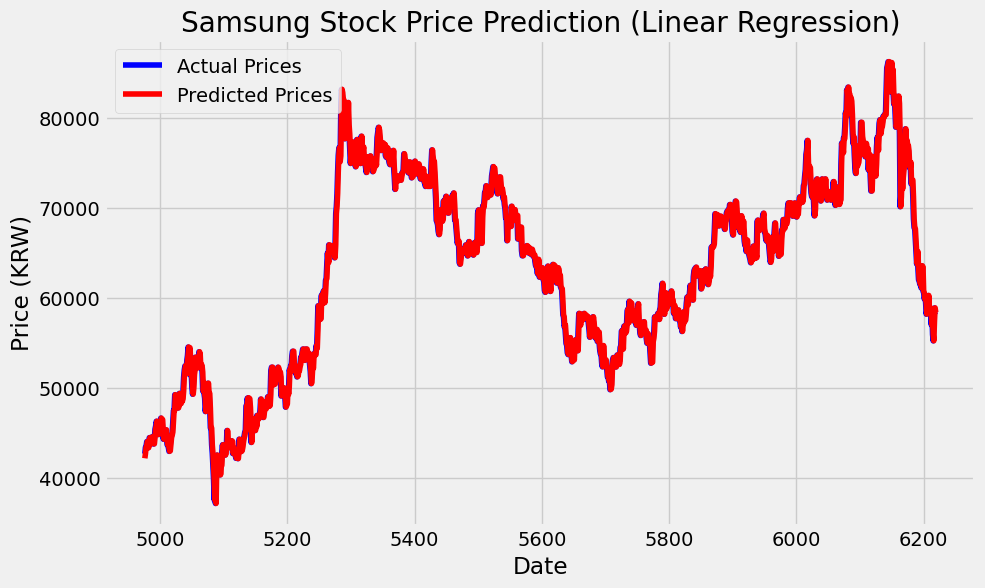

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(y_test.index, y_test, color='blue', label='Actual Prices')
plt.plot(y_test.index, y_pred, color='red', label='Predicted Prices')
plt.title('Samsung Stock Price Prediction (Linear Regression)')
plt.xlabel('Date')
plt.ylabel('Price (KRW)')
plt.legend()
plt.show()
